In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [13]:
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes
...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes


In [14]:
df.isnull()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False
97,False,False,False,True,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [16]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())
df['Age_median_imputed']=df['Age'].fillna(df['Age'].median())

In [17]:
df['Education_mode_imputed']=df['Education'].fillna(df['Education'].mode([0]))
df['City_mode_imputed']=df['City'].fillna(df['City'].mode([0]))
df['Department_mode_imputed']=df['Department'].fillna(df['Department'].mode([0]))

In [18]:
df[['Age','Age_mean_imputed','Age_median_imputed','Education','Education_mode_imputed','City','City_mode_imputed','Department','Department_mode_imputed']]

,Age,Age_mean_imputed,Age_median_imputed,Education,Education_mode_imputed,City,City_mode_imputed,Department,Department_mode_imputed
0,59.0,59.0,59.0,Masters,Masters,Calicut,Calicut,HR,HR
1,49.0,49.0,49.0,Bachelors,Bachelors,Chennai,Chennai,Marketing,Marketing
2,35.0,35.0,35.0,NaN,NaN,Kochi,Kochi,HR,HR
3,28.0,28.0,28.0,PhD,PhD,Trivandrum,Trivandrum,HR,HR
4,41.0,41.0,41.0,Bachelors,Bachelors,Trivandrum,Trivandrum,IT,IT
...,...,...,...,...,...,...,...,...,...
95,54.0,54.0,54.0,Masters,Masters,Chennai,Chennai,HR,HR
96,53.0,53.0,53.0,Masters,Masters,Trivandrum,Trivandrum,Marketing,Marketing
97,43.0,43.0,43.0,PhD,PhD,Chennai,Chennai,NaN,NaN
98,44.0,44.0,44.0,PhD,PhD,Calicut,Calicut,Marketing,Marketing


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

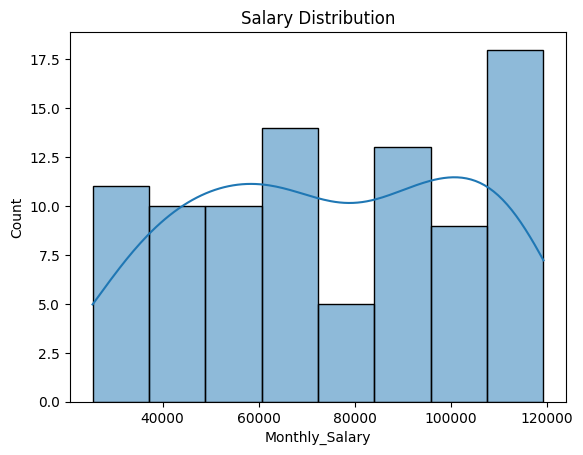

In [20]:
sns.histplot(df['Monthly_Salary'], kde=True)
plt.title('Salary Distribution')
plt.show()

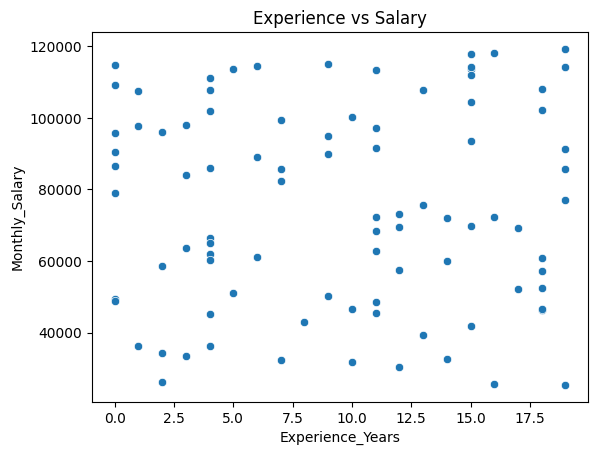

In [21]:
sns.scatterplot(data=df, x='Experience_Years', y='Monthly_Salary')
plt.title('Experience vs Salary')
plt.show()

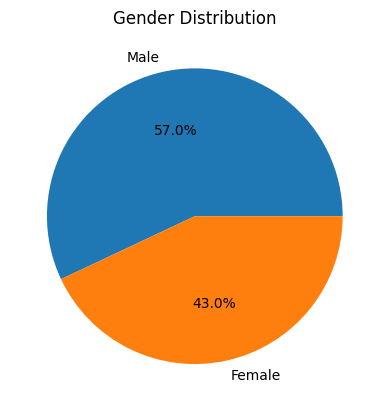

In [22]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

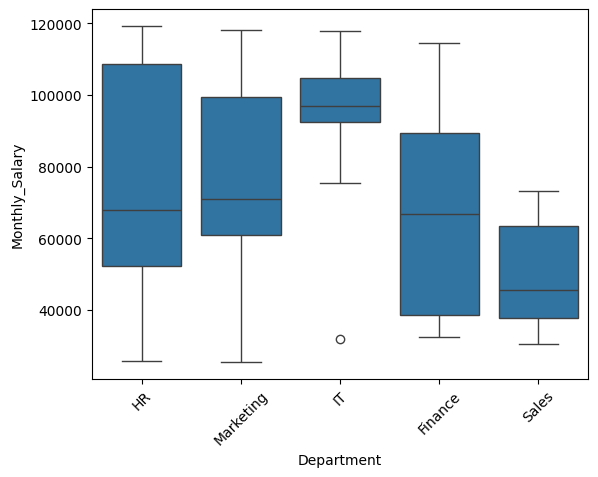

In [23]:
sns.boxplot(data=df, x='Department', y='Monthly_Salary')
plt.xticks(rotation=45)
plt.show()

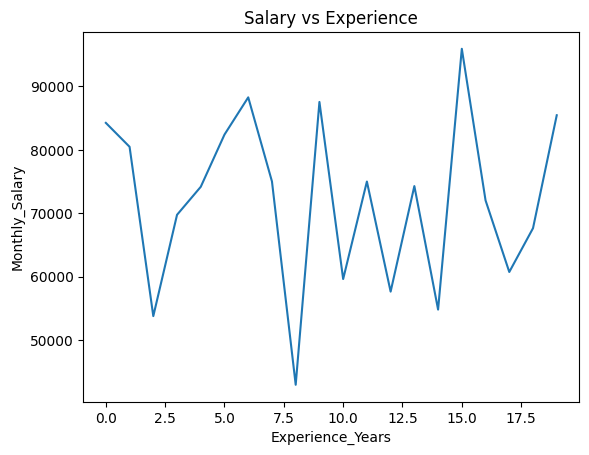

In [24]:
salary_exp = df.groupby('Experience_Years')['Monthly_Salary'].mean().reset_index()

sns.lineplot(
    data=salary_exp,
    x='Experience_Years',
    y='Monthly_Salary'
)
plt.title('Salary vs Experience')
plt.show()

In [27]:
from sklearn.preprocessing import LabelEncoder

# Read dataset
content_data = pd.read_csv('/content/preprocessing_practice_dataset.csv')

# Create copy
encoded_data = content_data.copy()

# Label Encoding
label_encoder = LabelEncoder()
encoded_data['Gender_Label'] = label_encoder.fit_transform(
    encoded_data['Gender']
)

# One-Hot Encoding
one_hot_encoded = pd.get_dummies(
    encoded_data['Department'],
    prefix='Department'
)

encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

print(encoded_data.head())

   Employee_ID   Age  Gender Department  Education  Experience_Years  \
0         1001  59.0    Male         HR    Masters                18   
1         1002  49.0  Female  Marketing  Bachelors                16   
2         1003  35.0  Female         HR        NaN                19   
3         1004  28.0  Female         HR        PhD                 9   
4         1005  41.0    Male         IT  Bachelors                 5   

   Monthly_Salary  Performance_Rating        City Attrition  Gender_Label  \
0         52350.0                   5     Calicut        No             1   
1        118008.0                   2     Chennai       Yes             0   
2        119297.0                   1       Kochi       Yes             0   
3         50351.0                   2  Trivandrum       Yes             0   
4        113668.0                   3  Trivandrum       Yes             1   

   Department_Finance  Department_HR  Department_IT  Department_Marketing  \
0               False      

In [28]:
one_hot_encoded = pd.get_dummies(encoded_data['Department'], prefix='Department')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)
print(encoded_data[['Gender', 'Gender_Label', 'Department', ]].head())

   Gender  Gender_Label Department
0    Male             1         HR
1  Female             0  Marketing
2  Female             0         HR
3  Female             0         HR
4    Male             1         IT


In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [30]:
File_path = '/content/preprocessing_practice_dataset.csv'

In [31]:
content_data = pd.read_csv(File_path)

In [32]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numerical_columns = ['Age', 'Experience_Years', 'Monthly_Salary']

content_data.dropna(subset=numerical_columns, inplace=True)

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# MinMax Scaling
content_data['Age_MinMax'] = minmax_scaler.fit_transform(content_data[['Age']])

content_data['Experience_Years_MinMax'] = minmax_scaler.fit_transform(
    content_data[['Experience_Years']]
)

# Standard Scaling
content_data['Age_Standard'] = standard_scaler.fit_transform(
    content_data[['Age']]
)

content_data['Experience_Years_Standard'] = standard_scaler.fit_transform(
    content_data[['Experience_Years']]
)

content_data[['Age',
              'Age_MinMax',
              'Age_Standard',
              'Experience_Years_MinMax',
              'Experience_Years_Standard']].head()

,Age,Age_MinMax,Age_Standard,Experience_Years_MinMax,Experience_Years_Standard
0,59.0,1.000000,1.811984,0.947368,1.408639
1,49.0,0.736842,0.889855,0.842105,1.085278
2,35.0,0.368421,-0.401126,1.000000,1.570319
3,28.0,0.184211,-1.046617,0.473684,-0.046483
4,41.0,0.526316,0.152151,0.263158,-0.693204
